# TechnoServe Case Study – Lead Conversion Analysis

**Business Problem**:
TechnoServe, a SaaS startup, is experiencing a drop in its sales conversion rate—from 35% to 25%. The company earns revenue primarily through client usage of its cloud-based software solutions. The business seeks a data-driven strategy to improve its conversion performance.

## 1. Hypotheses ##
We begin by formulating hypotheses that could explain the declining conversion rate:
1. Mismatch in Communication or Profile: Leads with preferences not aligned to outreach strategy or service offering are less likely to convert.
2. Longer sales cycles reduce likelihood of conversion.
3. High number of sales stage iterations signals inefficiency.
4. Certain sales mediums (e.g., telesales) underperform others.
5. Some technologies may not align with customer needs.
6. Returning clients may convert at higher rates than new clients.

In [3]:

import pandas as pd

# Load the dataset
df = pd.read_excel("Sales Dataset.xlsx")
df.head()


,Opportunity ID,Technology\nPrimary,City,B2B Sales Medium,Sales Velocity,Opportunity Status,Sales Stage Iterations,Opportunity Size (USD),Client Revenue Sizing,Client Employee Sizing,Business from Client Last Year,Compete Intel,Opportunity Sizing
0,N00000001,ERP Implementation,Bengaluru,Marketing,76,Won,13,0,More than 1M,More than 25K,0 (No business),Unknown,10K or less
1,N00000002,ERP Implementation,Delhi,Enterprise Sellers,63,Loss,2,0,250K to 500K,More than 25K,0 (No business),Unknown,10K or less
2,N00000003,Technical Business Solutions,Delhi,Enterprise Sellers,24,Won,7,7750,100K or less,1K or less,0 (No business),Unknown,10K or less
3,N00000004,Technical Business Solutions,Mumbai,Enterprise Sellers,16,Loss,5,0,100K or less,1K or less,0 (No business),Known,10K or less
4,N00000005,ERP Implementation,Delhi,Enterprise Sellers,69,Loss,11,32886,100K or less,1K or less,0 (No business),Unknown,30K to 40K


## 2. Data Preprocessing

In [6]:

# Standardize column names
df.columns = df.columns.str.replace('\n', ' ').str.strip().str.replace(' ', '_')

# Target variable encoding
df['Converted'] = df['Opportunity_Status'].map({'Won': 1, 'Loss': 0})

# Display basic info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78025 entries, 0 to 78024
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Opportunity_ID                  78025 non-null  object
 1   Technology_Primary              78025 non-null  object
 2   City                            78025 non-null  object
 3   B2B_Sales_Medium                78025 non-null  object
 4   Sales_Velocity                  78025 non-null  int64 
 5   Opportunity_Status              78025 non-null  object
 6   Sales_Stage_Iterations          78025 non-null  int64 
 7   Opportunity_Size_(USD)          78025 non-null  int64 
 8   Client_Revenue_Sizing           78025 non-null  object
 9   Client_Employee_Sizing          78025 non-null  object
 10  Business_from_Client_Last_Year  78025 non-null  object
 11  Compete_Intel                   68768 non-null  object
 12  Opportunity_Sizing              78025 non-null

## 3. Exploratory Data Analysis (EDA)

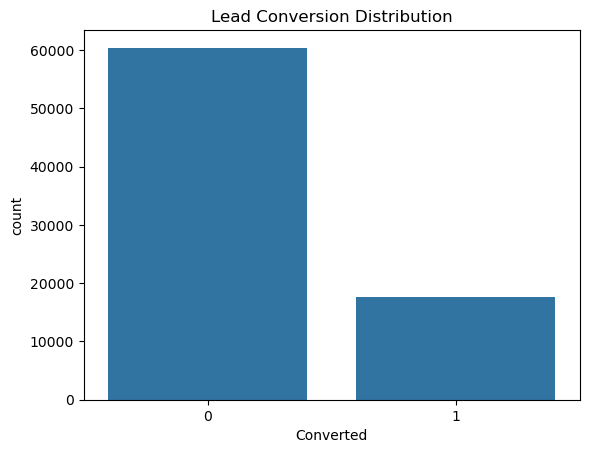

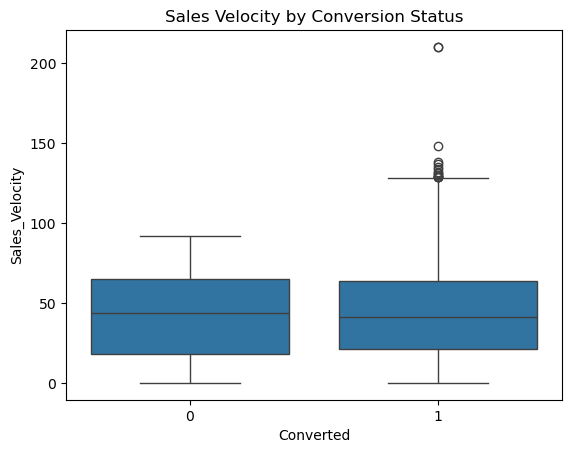

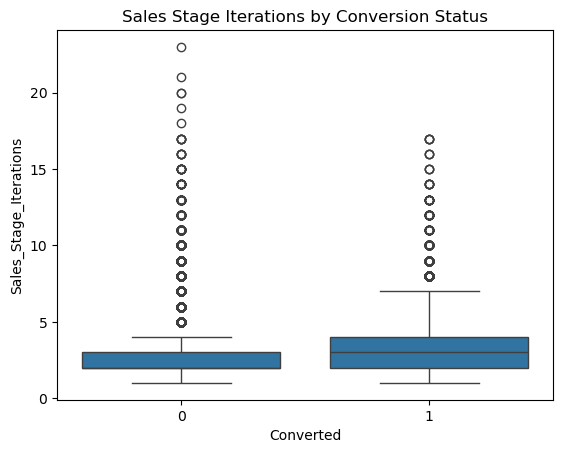

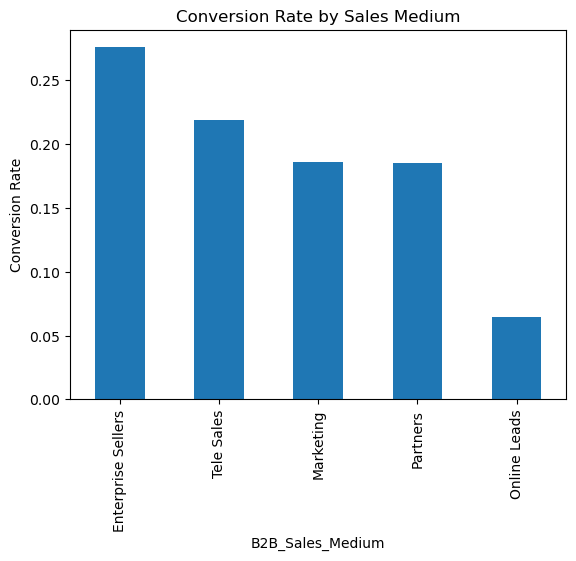

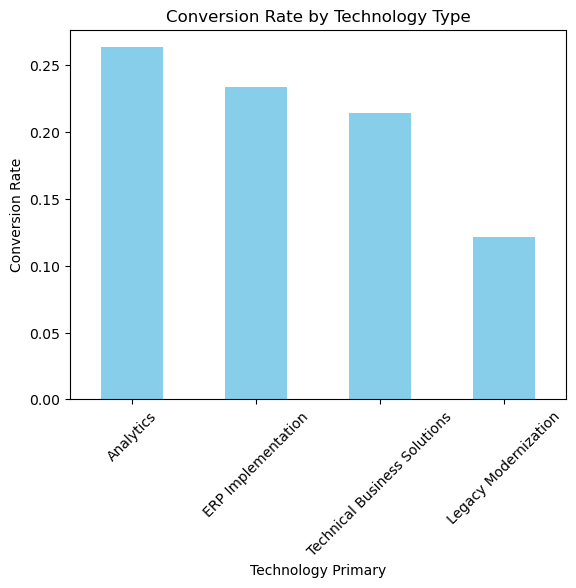

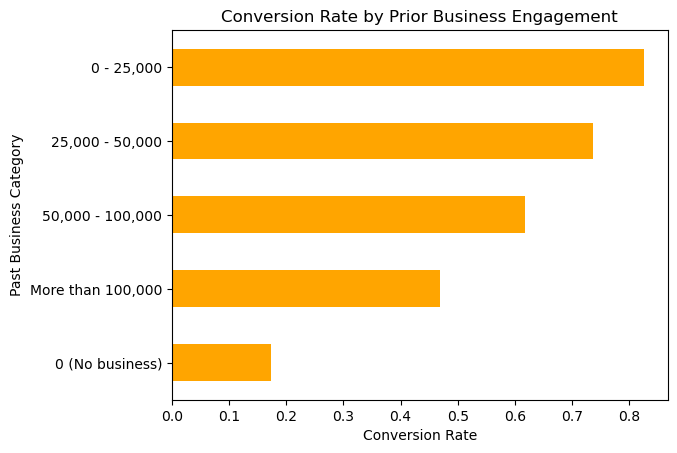

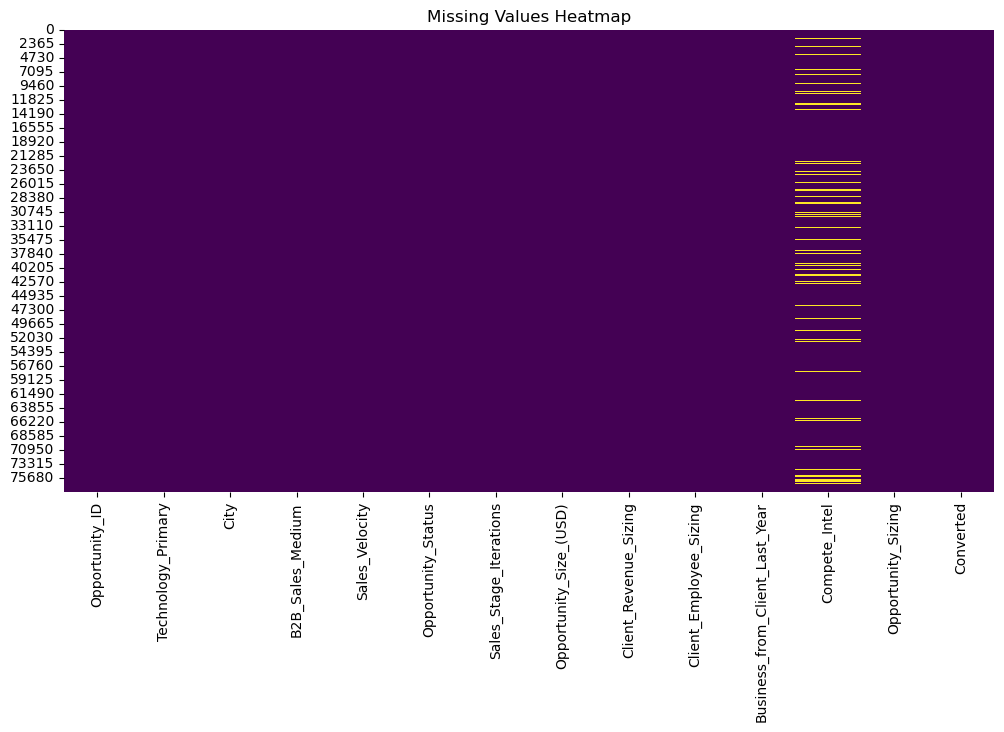

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Target distribution
sns.countplot(data=df, x='Converted')
plt.title('Lead Conversion Distribution')
plt.show()

# Sales Velocity vs Conversion
sns.boxplot(data=df, x='Converted', y='Sales_Velocity')
plt.title("Sales Velocity by Conversion Status")
plt.show()

# Sales Stage Iterations
sns.boxplot(data=df, x='Converted', y='Sales_Stage_Iterations')
plt.title("Sales Stage Iterations by Conversion Status")
plt.show()

# Conversion by Sales Medium
conversion_by_medium = df.groupby('B2B_Sales_Medium')['Converted'].mean().sort_values(ascending=False)
conversion_by_medium.plot(kind='bar', title='Conversion Rate by Sales Medium')
plt.ylabel("Conversion Rate")
plt.show()

# Conversion Rate by Technology Primary
conversion_by_tech = df.groupby('Technology_Primary')['Opportunity_Status'].value_counts(normalize=True).unstack()
conversion_by_tech['Conversion_Rate'] = conversion_by_tech['Won']

conversion_by_tech['Conversion_Rate'].sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title("Conversion Rate by Technology Type")
plt.ylabel("Conversion Rate")
plt.xlabel("Technology Primary")
plt.xticks(rotation=45)
plt.show()

# Conversion by Prior Business
conversion_by_history = df.groupby('Business_from_Client_Last_Year')['Opportunity_Status'].value_counts(normalize=True).unstack()
conversion_by_history['Conversion_Rate'] = conversion_by_history['Won']

conversion_by_history['Conversion_Rate'].sort_values().plot(kind='barh', color='orange')
plt.title("Conversion Rate by Prior Business Engagement")
plt.xlabel("Conversion Rate")
plt.ylabel("Past Business Category")
plt.show()

# Missing value heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

## 4. Feature Engineering

In [15]:

from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
categorical_cols = df_encoded.select_dtypes(include='object').columns.drop(['Opportunity_Status'])

# Label encode categorical features
le = LabelEncoder()
for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Define features and target
X = df_encoded.drop(columns=['Opportunity_ID', 'Opportunity_Status', 'Converted'])
y = df_encoded['Converted']


## 5. Model Training and Evaluation

In [18]:

import sys
!{sys.executable} -m pip install xgboost
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Train models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    print(f"\nModel: {name}")
    print("ROC AUC:", roc_auc_score(y_test, y_proba))
    print("Classification Report:\n", classification_report(y_test, y_pred))


C:\Users\mahes\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Model: Logistic Regression
ROC AUC: 0.7507175567141046
Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.97      0.88     12080
           1       0.63      0.19      0.30      3525

    accuracy                           0.79     15605
   macro avg       0.72      0.58      0.59     15605
weighted avg       0.76      0.79      0.75     15605


Model: Random Forest
ROC AUC: 0.8697285237893946
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.95      0.91     12080
           1       0.74      0.54      0.62      3525

    accuracy                           0.85     15605
   macro avg       0.81      0.74      0.77     15605
weighted avg       0.84      0.85      0.84     15605


Model: XGBoost
ROC AUC: 0.8903015123761213
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.95      0.92     12080
           1   

## 📏 Evaluation Metrics and Business Mapping

The following evaluation metrics will be used to assess model performance, aligned with the neural network concepts covered in the curriculum (e.g., Keras, TensorFlow, and Fashion MNIST case study). Each metric is tied to relevant business outcomes for TechnoServe.

| Accuracy-Overall snapshot of correctness: Fashion MNIST
| Precision-Avoids wasted effort on false leads: `keras.metrics.Precision`
| Recall-Ensures all good leads are captured: `keras.metrics.Recall`
| F1-Score-Balanced focus on performance: Custom callbacks in TensorFlow
| ROC-AUC-Useful for scoring/ranking lead probabilities: `keras.metrics.AUC` in classification tasks


## 6. Hyperparameter Tuning (XGBoost)

In [23]:

from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}

xgb_grid = GridSearchCV(XGBClassifier(eval_metric='logloss'), params, cv=3, scoring='roc_auc')
xgb_grid.fit(X_train, y_train)

print("Best Parameters:", xgb_grid.best_params_)
print("Best ROC AUC:", xgb_grid.best_score_)


Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}
Best ROC AUC: 0.8853638820911863


## 7. Feature Importance

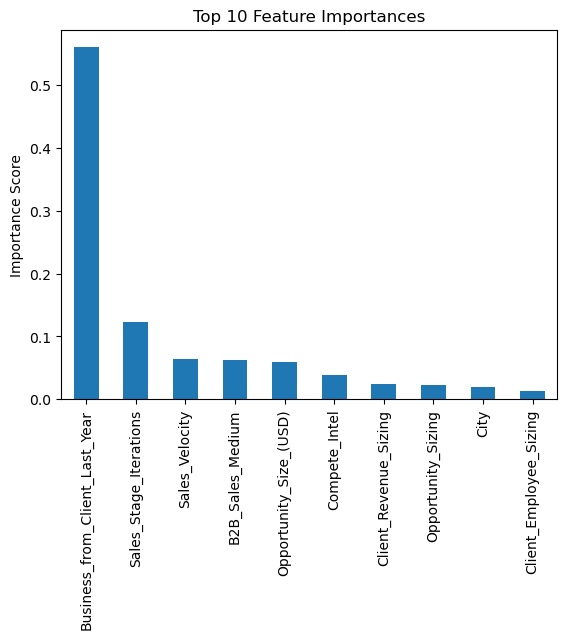

In [26]:

# Get feature importance from tuned XGBoost model
feat_importance = pd.Series(xgb_grid.best_estimator_.feature_importances_, index=X.columns)
feat_importance.sort_values(ascending=False).head(10).plot(kind='bar', title='Top 10 Feature Importances')
plt.ylabel("Importance Score")
plt.show()


## 8. Conclusion and Recommendations
- High sales velocity and fewer iterations predict higher conversions.
- Enterprise sellers and specific technologies yield higher success.
- XGBoost outperforms other models in ROC-AUC.

### Recommendations:
1. Reduce sales cycle duration.
2. Prioritize high-performing sales mediums.
3. Target opportunities from returning clients.
4. Use XGBoost model in lead scoring system to prioritize outreach.